Import Libraries and Dependencies

In [34]:
import os
import tarfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

## Download and Extract the 17 Flowers Dataset

This cell downloads the flower images and trimap masks, then unpacks them into a local working directory so the rest of the notebook can load the dataset from disk.

In [35]:
!wget -q https://www.robots.ox.ac.uk/~vgg/data/flowers/17/17flowers.tgz
!wget -q https://www.robots.ox.ac.uk/~vgg/data/flowers/17/trimaps.tgz

!mkdir -p /content/flowers17
!tar -xzf 17flowers.tgz -C /content/flowers17
!tar -xzf trimaps.tgz -C /content/flowers17

print(os.listdir("/content/flowers17"))

['jpg', 'trimaps']


## Build the Image-Mask Metadata Table

This cell pairs each flower image with its corresponding trimap mask and class label, creating a dataframe that keeps the classification and segmentation workflows aligned.

In [36]:
image_dir = "/content/flowers17/jpg"
mask_dir = "/content/flowers17/trimaps"

image_files = sorted([
    f for f in os.listdir(image_dir)
    if f.lower().endswith(".jpg")
])

mask_files = sorted([
    f for f in os.listdir(mask_dir)
    if f.lower().endswith(".png")
])

print("Number of images:", len(image_files))
print("Number of masks:", len(mask_files))

data = []

for i, img_name in enumerate(image_files):
    class_id = i // 80

    if class_id >= 17:
        continue

    class_name = f"class_{class_id}"

    img_path = os.path.join(image_dir, img_name)

    # Try both possible mask names
    mask_name_1 = img_name.replace(".jpg", ".png")                # image_0001.png
    mask_name_2 = img_name.replace("image_", "trimap_").replace(".jpg", ".png")  # trimap_0001.png

    mask_path_1 = os.path.join(mask_dir, mask_name_1)
    mask_path_2 = os.path.join(mask_dir, mask_name_2)

    if os.path.exists(mask_path_1):
        mask_path = mask_path_1
    elif os.path.exists(mask_path_2):
        mask_path = mask_path_2
    else:
        continue

    data.append([img_path, mask_path, class_name])

df = pd.DataFrame(data, columns=["image_path", "mask_path", "class_name"])

print(df.head())
print("Total matched image-mask pairs:", len(df))
print("Total classes:", df["class_name"].nunique())
print(df["class_name"].value_counts().sort_index())

Number of images: 1360
Number of masks: 848
                              image_path  \
0  /content/flowers17/jpg/image_0001.jpg   
1  /content/flowers17/jpg/image_0002.jpg   
2  /content/flowers17/jpg/image_0003.jpg   
3  /content/flowers17/jpg/image_0004.jpg   
4  /content/flowers17/jpg/image_0005.jpg   

                                   mask_path class_name  
0  /content/flowers17/trimaps/image_0001.png    class_0  
1  /content/flowers17/trimaps/image_0002.png    class_0  
2  /content/flowers17/trimaps/image_0003.png    class_0  
3  /content/flowers17/trimaps/image_0004.png    class_0  
4  /content/flowers17/trimaps/image_0005.png    class_0  
Total matched image-mask pairs: 848
Total classes: 16
class_name
class_0     71
class_1     50
class_10    57
class_11    43
class_12    55
class_14    54
class_15    63
class_16    56
class_2     17
class_3     28
class_4     50
class_5     78
class_6     49
class_7     41
class_8     65
class_9     71
Name: count, dtype: int64


## Create a Stratified Train/Validation Split

This cell splits the dataframe into training and validation sets while preserving the class distribution, which makes the evaluation more representative.

In [37]:
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["class_name"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))

Train: 678
Validation: 170


## Prepare VGG19 Data Generators

This cell applies VGG19 preprocessing and light augmentation to the training set, then builds generators that stream resized batches into the classifier.

In [38]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    horizontal_flip=True,
    zoom_range=0.15,
    rotation_range=10
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col="image_path",
    y_col="class_name",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

val_gen = val_datagen.flow_from_dataframe(
    val_df,
    x_col="image_path",
    y_col="class_name",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

NUM_CLASSES = len(train_gen.class_indices)

print("Number of classes:", NUM_CLASSES)
print(train_gen.class_indices)

Found 678 validated image filenames belonging to 16 classes.
Found 170 validated image filenames belonging to 16 classes.
Number of classes: 16
{'class_0': 0, 'class_1': 1, 'class_10': 2, 'class_11': 3, 'class_12': 4, 'class_14': 5, 'class_15': 6, 'class_16': 7, 'class_2': 8, 'class_3': 9, 'class_4': 10, 'class_5': 11, 'class_6': 12, 'class_7': 13, 'class_8': 14, 'class_9': 15}


## Switch to VGG19-Specific Imports

This cell imports the VGG19 backbone and matching preprocessing utilities needed to build the classifier with the correct ImageNet-style input pipeline.

In [39]:
from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications.vgg19 import preprocess_input

## Build the VGG19 Classifier

This cell loads the pretrained VGG19 backbone, freezes its feature layers, adds a small custom classification head, and compiles the model for the 17-class flower task.

In [40]:
vgg_base = VGG19(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

for layer in vgg_base.layers:
    layer.trainable = False

x = vgg_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.4)(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)

vgg_model = Model(inputs=vgg_base.input, outputs=output)

vgg_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

vgg_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 20,159,824 (76.90 MB)

 Trainable params: 135,440 (529.06 KB)

 Non-trainable params: 20,024,384 (76.39 MB)

## Train the VGG19 Classifier

This cell fits the classifier for a small number of epochs so the notebook can compare training and validation behavior before moving on to evaluation.

In [41]:
EPOCHS = 10

vgg_history = vgg_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS
)

Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 801ms/step - accuracy: 0.0811 - loss: 8.9034 - val_accuracy: 0.0882 - val_loss: 5.3615
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 13s 569ms/step - accuracy: 0.1165 - loss: 6.9793 - val_accuracy: 0.2235 - val_loss: 3.8856
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 13s 578ms/step - accuracy: 0.1991 - loss: 5.3745 - val_accuracy: 0.2941 - val_loss: 3.0433
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 12s 550ms/step - accuracy: 0.2286 - loss: 4.5303 - val_accuracy: 0.4118 - val_loss: 2.4345
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 12s 530ms/step - accuracy: 0.3038 - loss: 3.6114 - val_accuracy: 0.4706 - val_loss: 2.0565
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 515ms/step - accuracy: 0.3761 - loss: 3.0746 - val_accuracy: 0.5176 - val_loss: 1.7372
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 21s 558ms/step - accuracy: 0.4440 - loss: 2.5146 - val_accuracy: 0.6059 - val_loss: 1.4798
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 13s 571ms/step - accuracy: 0.4499 - loss: 2.3434 - val_accu

## Evaluate the VGG19 Classifier

This cell measures validation loss and accuracy on the held-out split, giving a quick summary of how well the trained model generalizes.

In [42]:
val_loss, val_acc = vgg_model.evaluate(val_gen)

print("VGG19 Validation Accuracy:", round(val_acc * 100, 2), "%")
print("VGG19 Validation Loss:", round(val_loss, 4))

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 217ms/step - accuracy: 0.7118 - loss: 1.0716
VGG19 Validation Accuracy: 71.18 %
VGG19 Validation Loss: 1.0716


## Plot the Training Curves

This cell plots accuracy and loss over the epochs so you can see whether the model is learning steadily or drifting into overfitting.

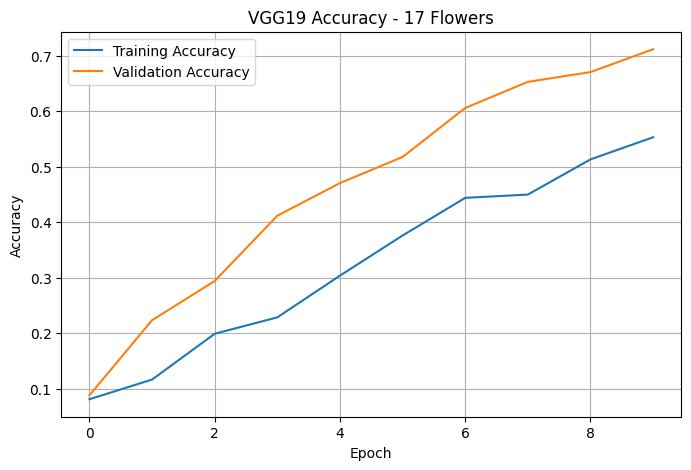

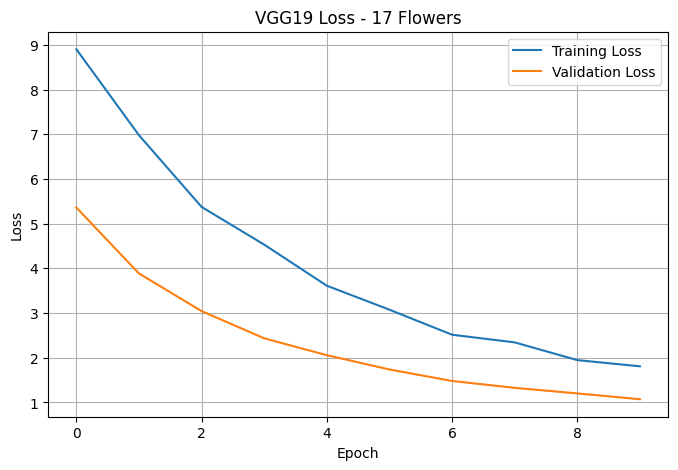

In [43]:
plt.figure(figsize=(8, 5))
plt.plot(vgg_history.history["accuracy"], label="Training Accuracy")
plt.plot(vgg_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("VGG19 Accuracy - 17 Flowers")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(vgg_history.history["loss"], label="Training Loss")
plt.plot(vgg_history.history["val_loss"], label="Validation Loss")
plt.title("VGG19 Loss - 17 Flowers")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

## Inspect Predictions with a Confusion Matrix

This cell converts model probabilities into class labels, then uses a confusion matrix and classification report to show which flower classes are most often confused.

6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 411ms/step


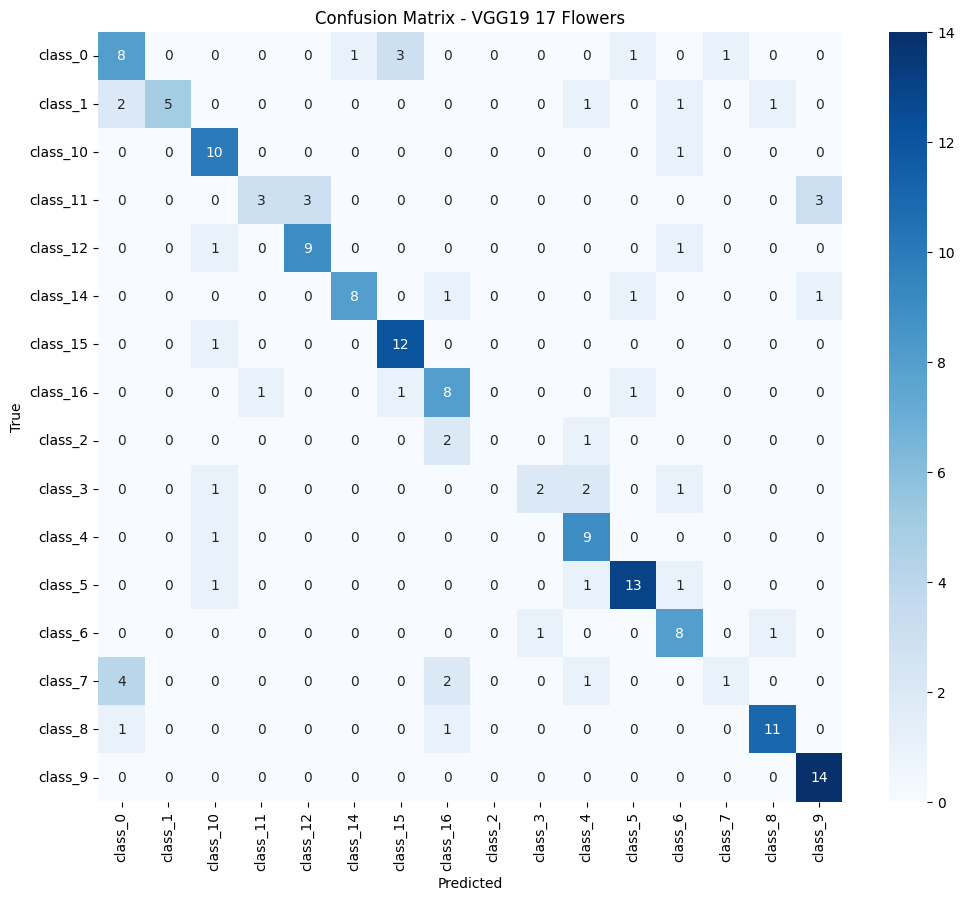

              precision    recall  f1-score   support

     class_0       0.53      0.57      0.55        14
     class_1       1.00      0.50      0.67        10
    class_10       0.67      0.91      0.77        11
    class_11       0.75      0.33      0.46         9
    class_12       0.75      0.82      0.78        11
    class_14       0.89      0.73      0.80        11
    class_15       0.75      0.92      0.83        13
    class_16       0.57      0.73      0.64        11
     class_2       0.00      0.00      0.00         3
     class_3       0.67      0.33      0.44         6
     class_4       0.60      0.90      0.72        10
     class_5       0.81      0.81      0.81        16
     class_6       0.62      0.80      0.70        10
     class_7       0.50      0.12      0.20         8
     class_8       0.85      0.85      0.85        13
     class_9       0.78      1.00      0.88        14

    accuracy                           0.71       170
   macro avg       0.67   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [44]:
val_gen.reset()

predictions = vgg_model.predict(val_gen)
y_pred = np.argmax(predictions, axis=1)
y_true = val_gen.classes

class_labels = list(val_gen.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.title("Confusion Matrix - VGG19 17 Flowers")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print(classification_report(y_true, y_pred, target_names=class_labels))

## Save the Trained VGG19 Model

This cell writes the trained classifier to disk so the model can be reused later without repeating the full training run.

In [45]:
vgg_model.save("/content/vgg19_17flowers.h5")
print("VGG19 model saved.")

VGG19 model saved.


## Segmentation Setup Imports

This cell imports the image-processing and plotting tools used by the segmentation pipeline, including OpenCV, PIL, NumPy, Matplotlib, and train/test splitting utilities.

In [46]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split

## Load Images and Ground-Truth Masks

This cell reads each flower image and its trimap mask, resizes them to a shared shape, and converts the masks into a simple flower-versus-background representation for evaluation.

In [47]:
SEG_SIZE = 128

def load_image(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (SEG_SIZE, SEG_SIZE))
    return img.astype(np.uint8)

def load_mask(path):
    mask = Image.open(path).convert("L")
    mask = np.array(mask)

    mask = cv2.resize(
        mask,
        (SEG_SIZE, SEG_SIZE),
        interpolation=cv2.INTER_NEAREST
    )

    # Flower = 1, Background = 0
    mask = np.where(mask > 0, 1, 0)

    return mask.astype(np.uint8)

X = np.array([load_image(p) for p in df["image_path"]])
Y = np.array([load_mask(p) for p in df["mask_path"]])

print("Images shape:", X.shape)
print("Masks shape:", Y.shape)
print("Mask values:", np.unique(Y))

Images shape: (848, 128, 128, 3)
Masks shape: (848, 128, 128)
Mask values: [0 1]


## Train/Validation Split

This cell creates a hold-out validation set for the segmentation experiments so the K-means masks can be checked on unseen images.

In [48]:
X_train, X_val, Y_train, Y_val = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

print("X_val:", X_val.shape)
print("Y_val:", Y_val.shape)

X_val: (170, 128, 128, 3)
Y_val: (170, 128, 128)


## K-Means Segmentation Function

This cell clusters image pixels by color so the notebook can separate the flower from the background using unsupervised segmentation.

In [49]:
def kmeans_segmentation(image, K=3):
    """
    image: RGB image, uint8, shape (H, W, 3)
    K: number of color clusters
    """

    h, w, c = image.shape

    pixels = image.reshape((-1, 3))
    pixels = np.float32(pixels)

    criteria = (
        cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,
        100,
        0.2
    )

    _, labels, centers = cv2.kmeans(
        pixels,
        K,
        None,
        criteria,
        10,
        cv2.KMEANS_RANDOM_CENTERS
    )

    centers = np.uint8(centers)
    labels = labels.flatten()

    clustered = centers[labels]
    clustered = clustered.reshape((h, w, 3))

    return clustered, labels.reshape((h, w)), centers

## Select Flower Cluster Automatically

This cell scores the color clusters using a center-versus-border heuristic, because flowers usually sit near the middle of the image while the background tends to dominate the edges.

In [33]:
def get_flower_mask_from_clusters(image, cluster_labels, centers):

    h, w = cluster_labels.shape

    center_region = cluster_labels[
        h//4:3*h//4,
        w//4:3*w//4
    ]

    border_pixels = np.concatenate([
        cluster_labels[0:10, :].flatten(),
        cluster_labels[-10:, :].flatten(),
        cluster_labels[:, 0:10].flatten(),
        cluster_labels[:, -10:].flatten()
    ])

    K = len(centers)

    center_counts = np.bincount(center_region.flatten(), minlength=K)
    border_counts = np.bincount(border_pixels.flatten(), minlength=K)

    scores = center_counts - border_counts

    flower_cluster = np.argmax(scores)

    mask = np.where(cluster_labels == flower_cluster, 1, 0)

    # Morphological cleanup
    mask = mask.astype(np.uint8)

    kernel = np.ones((5, 5), np.uint8)

    mask = cv2.morphologyEx(
        mask,
        cv2.MORPH_CLOSE,
        kernel,
        iterations=2
    )

    mask = cv2.morphologyEx(
        mask,
        cv2.MORPH_OPEN,
        kernel,
        iterations=1
    )

    return mask.astype(np.uint8)

## Segmentation Metrics

This cell defines IoU, Dice, and pixel accuracy so the predicted masks can be compared with the ground truth masks using standard overlap and correctness measures.

In [50]:
def compute_iou(y_true, y_pred):
    intersection = np.logical_and(y_true, y_pred).sum()
    union = np.logical_or(y_true, y_pred).sum()

    if union == 0:
        return 1.0

    return intersection / union

def compute_dice(y_true, y_pred):
    intersection = np.logical_and(y_true, y_pred).sum()

    return (2 * intersection + 1e-6) / (
        y_true.sum() + y_pred.sum() + 1e-6
    )

def compute_pixel_accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

## Evaluate K-Means on the Validation Set

This cell runs the segmentation pipeline across the validation images and aggregates the metrics so the notebook can summarize overall unsupervised performance.

In [51]:
ious = []
dices = []
accuracies = []

predicted_masks = []

for image, true_mask in zip(X_val, Y_val):

    clustered, labels, centers = kmeans_segmentation(
        image,
        K=3
    )

    pred_mask = get_flower_mask_from_clusters(
        image,
        labels,
        centers
    )

    predicted_masks.append(pred_mask)

    ious.append(compute_iou(true_mask, pred_mask))
    dices.append(compute_dice(true_mask, pred_mask))
    accuracies.append(compute_pixel_accuracy(true_mask, pred_mask))

print("K-Means Segmentation Results")
print("----------------------------")
print("Mean IoU:", round(np.mean(ious), 4))
print("Mean Dice Score:", round(np.mean(dices), 4))
print("Mean Pixel Accuracy:", round(np.mean(accuracies), 4))

K-Means Segmentation Results
----------------------------
Mean IoU: 0.3165
Mean Dice Score: 0.4635
Mean Pixel Accuracy: 0.3607


## Show Segmentation Results

This cell displays the original image, K-means clusters, ground truth mask, and predicted mask side by side so you can inspect the segmentation quality visually.

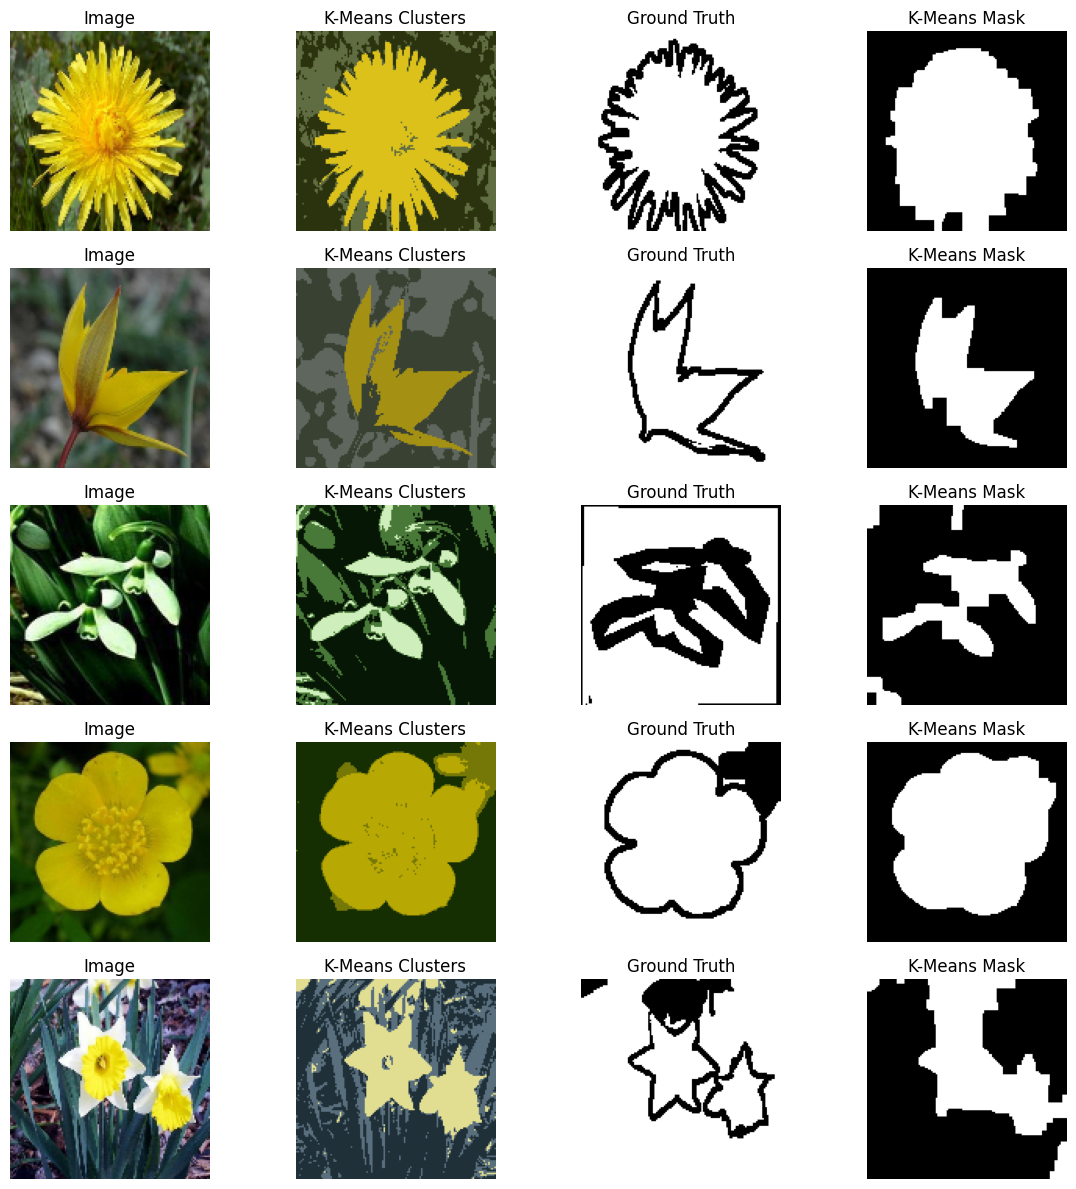

In [52]:
plt.figure(figsize=(12, 12))

for i in range(5):

    clustered, labels, centers = kmeans_segmentation(
        X_val[i],
        K=3
    )

    pred_mask = get_flower_mask_from_clusters(
        X_val[i],
        labels,
        centers
    )

    segmented_result = X_val[i] * pred_mask[:, :, np.newaxis]

    plt.subplot(5, 4, i * 4 + 1)
    plt.imshow(X_val[i])
    plt.title("Image")
    plt.axis("off")

    plt.subplot(5, 4, i * 4 + 2)
    plt.imshow(clustered)
    plt.title("K-Means Clusters")
    plt.axis("off")

    plt.subplot(5, 4, i * 4 + 3)
    plt.imshow(Y_val[i], cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(5, 4, i * 4 + 4)
    plt.imshow(pred_mask, cmap="gray")
    plt.title("K-Means Mask")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Test Different K Values

This cell sweeps several cluster counts to see how the segmentation metrics change, which helps identify a better K for the flower/background split.

In [31]:
K_values = [2, 3, 4, 5]

results = []

for K in K_values:

    ious = []
    dices = []
    accuracies = []

    for image, true_mask in zip(X_val, Y_val):

        clustered, labels, centers = kmeans_segmentation(
            image,
            K=K
        )

        pred_mask = get_flower_mask_from_clusters(
            image,
            labels,
            centers
        )

        ious.append(compute_iou(true_mask, pred_mask))
        dices.append(compute_dice(true_mask, pred_mask))
        accuracies.append(compute_pixel_accuracy(true_mask, pred_mask))

    results.append([
        K,
        np.mean(ious),
        np.mean(dices),
        np.mean(accuracies)
    ])

results_df = pd.DataFrame(
    results,
    columns=["K", "Mean IoU", "Mean Dice", "Mean Pixel Accuracy"]
)

results_df

,K,Mean IoU,Mean Dice,Mean Pixel Accuracy
0,2,0.422608,0.572036,0.448668
1,3,0.316279,0.463213,0.360508
2,4,0.269802,0.404644,0.328263
3,5,0.232535,0.361732,0.300456


## Plot K-Means Results

This cell plots the metric trends across different K values so the notebook can compare segmentation performance at a glance.

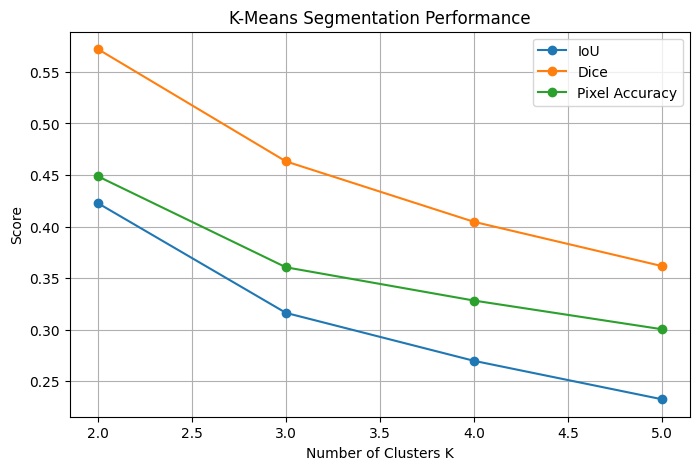

In [32]:
plt.figure(figsize=(8, 5))
plt.plot(results_df["K"], results_df["Mean IoU"], marker="o", label="IoU")
plt.plot(results_df["K"], results_df["Mean Dice"], marker="o", label="Dice")
plt.plot(results_df["K"], results_df["Mean Pixel Accuracy"], marker="o", label="Pixel Accuracy")
plt.title("K-Means Segmentation Performance")
plt.xlabel("Number of Clusters K")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()